# GDL - Midterm n.3

In the third midterm assignment, you are required to implement an **Adversarial Autoencoder (AAE)** ([Makhzani et al., 2015](https://arxiv.org/abs/1511.05644)).

An AAE is a generative model that regularises its latent space not through a closed-form KL divergence, but *adversarially*: a discriminator $D_\psi$ is trained to distinguish latent codes produced by the encoder $z \sim q_\phi(z|x)$ from samples drawn from the chosen prior $p(z)$; the encoder is also simultaneously trained as a generator that tries to fool $D_\psi$.

⚠️ Read **carefully** the project description and in particular the **evaluation subsection**!

## Project Description

### Model
The three networks are:
- **Encoder** $q_\phi(z\mid x)$: maps an image $x$ to a latent code $z \in \mathbb{R}^d$.
- **Decoder** $p_\theta(\hat x\mid z)$: reconstructs $x$ from $z$.
- **Discriminator** $D_\psi(z) \in [0,1]$: estimates the probability that $z$ comes from the prior $p(z) = \mathcal{N}(\mathbf{0}, I)$.

### Training Objectives

Training alternates between two phases per mini-batch:

*Phase 1 — Reconstruction.* Update encoder $\phi$ and decoder $\theta$ to minimise the reconstruction loss:
$$
\mathcal{L}_{\text{recon}} = -\mathbb{E}_{p(x)}\bigl[\log p_\theta(x \mid q_\phi(x))\bigr]
\approx \mathrm{BCE}(\hat x, x).
$$

*Phase 2 — Adversarial regularisation.* Two gradient steps:

1. **Discriminator step** — update $\psi$ to distinguish prior samples (labelled *real*) from encoder outputs (labelled *fake*):
$$
\mathcal{L}_{D} = -\mathbb{E}_{z \sim p(z)}[\log D_\psi(z)] - \mathbb{E}_{x \sim p(x)}[\log(1 - D_\psi(q_\phi(x)))].
$$

2. **Generator step** — update $\phi$ only, to fool the discriminator:
$$
\mathcal{L}_{G} = -\mathbb{E}_{x \sim p(x)}[\log D_\psi(q_\phi(x))].
$$

Note that three separate optimisers are required: `opt_ae` (encoder + decoder), `opt_disc` (discriminator), `opt_gen` (encoder only).

### Summary

You are required to:
1. **Implement the `Encoder` module.**
2. **Implement the `Decoder` module.**
3. **Implement the `Discriminator` module.**
4. **Implement the `AdversarialAutoencoder` wrapper**, exposing `encode`, `decode`, `forward`, `sample`, `reconstruction_loss`, and `adversarial_losses`.
5. **Implement the `train_aae` function** with the two-phase training loop and three optimisers.

In the code stubs, you will find suggestions for the hyperparameters and the architecture. They should be a good starting point, but feel free to play around.

### 🚨 Evaluation

You are required to submit a Notebook where all cells have been runned. The bare minimum to pass the midterm is the *Synthetic* dataset, but feel free to play with Small-MNIST or MNIST. We will check the quality of reconstructions and the training loss trend. Then, we will run again your notebook and check whether results are coherent with what you produced. Therefore, do not alter the seeds and ensure your notebook handles a fresh end-to-end run. For your learning experience, we require you to refrain from using LLM-generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 1, 3, and 4 of the notebook.**

In [85]:
# your student "matricola" goes here
student_id = 660903
# the ID from the sheet circulated in classroom goes here
submission_id = 17
# the dataset you are going to use
DATASET = "Synthetic"  # options: "Synthetic", "Small-MNIST", "MNIST"

assert student_id is not None and submission_id is not None, \
    "Fill the student_id and submission_id before submitting!"

### 1. Libraries and Data Loading

**Do not alter this section.**

In [86]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [87]:
if DATASET == "Synthetic":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']
elif DATASET == "Small-MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = list(range(NUM_CLASSES))
elif DATASET == "MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 10
    CLASSES = list(range(NUM_CLASSES))
else:
    raise ValueError("Unknown dataset.")

BATCH_SIZE = 128
INPUT_DIM = IMG_SIZE * IMG_SIZE

print(f"Dataset: {DATASET} ({INPUT_DIM} → {NUM_CLASSES}) | batch size {BATCH_SIZE}")

Dataset: Synthetic (784 → 4) | batch size 128


In [88]:
# Synthetic data: 2D Gaussian blobs at random positions in 4 quadrants
def get_synthetic_data(n, sz=28):
    images = np.zeros((n, sz, sz), dtype=np.float32)
    labels = np.zeros(n, dtype=np.int64)
    sigma = max(1.0, sz / 12)                # blob scale; fades to ~0 well before the border
    margin = 3 * sigma                       # keep most of the mass inside the frame
    mid = sz / 2
    ys, xs = np.mgrid[0:sz, 0:sz]
    for i in range(n):
        cx = np.random.uniform(margin, sz - margin - 1)
        cy = np.random.uniform(margin, sz - margin - 1)
        images[i] = np.exp(-((xs - cx)**2 + (ys - cy)**2) / (2 * sigma**2)).astype(np.float32)
        labels[i] = (cx >= mid) + 2 * (cy >= mid)
    return torch.from_numpy(images), torch.from_numpy(labels)


if DATASET == "Synthetic":
    x_train, y_train = get_synthetic_data(8000, sz=IMG_SIZE)
    x_test,  y_test  = get_synthetic_data(2000, sz=IMG_SIZE)
    train_dataset = TensorDataset(x_train.view(-1, 1, IMG_SIZE, IMG_SIZE), y_train)
    test_dataset  = TensorDataset(x_test.view(-1, 1, IMG_SIZE, IMG_SIZE),  y_test)
else:
    transform = transforms.Compose([transforms.ToTensor()])
    full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
    full_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    def filter_digits(dataset, digits):
        digit_set = set(digits)
        indices = [i for i, (_, y) in enumerate(dataset) if y in digit_set]
        return Subset(dataset, indices)

    train_dataset = filter_digits(full_train, CLASSES)
    test_dataset  = filter_digits(full_test, CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train set: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"Test set:  {len(test_dataset)} samples ({len(test_loader)} batches)")

Train set: 8000 samples (63 batches)
Test set:  2000 samples (16 batches)


In [89]:
def show_reconstructions(model, data_loader, n=10, title="Reconstructions"):
    """Display original images alongside their reconstructions."""
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(data_loader))
        x = x.to(device)[:n]
        recon = model(x)[0]
    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("$x$", fontsize=10)
    axes[1, 0].set_title(r"$\hat{x}$", fontsize=10)
    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def show_samples(model, n=10, title="Samples from Prior"):
    """Draw latent vectors from the prior, decode, and display."""
    model.eval()
    with torch.no_grad():
        samples = model.sample(n).cpu()
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    for i in range(n):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(title, fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()


def plot_losses(loss_dict: dict, title="Training Loss"):
    """Plot one curve per key in loss_dict."""
    plt.figure(figsize=(8, 4))
    for label, values in loss_dict.items():
        plt.plot(values, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_latent_space(model, data_loader, title="Latent Space"):
    """Scatter-plot the first two latent dimensions, coloured by digit class."""
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            z = model.encode(x)
            zs.append(z[:, :2].cpu())
            ys.append(y)
    zs = torch.cat(zs)
    ys = torch.cat(ys)
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(zs[:, 0], zs[:, 1], c=ys, cmap="tab10",
                          s=1, alpha=0.5, vmin=0, vmax=9)
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.tight_layout()
    plt.show()


def discriminator_accuracy(model, data_loader, n_batches=10):
    """
    Estimate discriminator accuracy on held-out real vs. fake latent codes.
    A well-trained AAE should push this towards 50 % (discriminator confused).
    """
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            if i >= n_batches:
                break
            x = x.to(device)
            n = x.size(0)
            z_fake = model.encode(x)
            z_real = torch.randn(n, model.latent_dim).to(device)
            # discriminator outputs: >0.5 → predicted real
            pred_real = (model.discriminator(z_real) > 0.5).float()
            pred_fake = (model.discriminator(z_fake) > 0.5).float()
            correct += pred_real.sum().item() + (1 - pred_fake).sum().item()
            total   += 2 * n
    acc = correct / total
    print(f"Discriminator accuracy (real vs. fake): {acc:.4f}  (ideal ≈ 0.50)")
    return acc

def show_latent_traversal(model, dim_to_traverse=0, n_steps=10, z_range=(-3, 3), title="Traversal"):
    model.eval()
    with torch.no_grad():
        z = torch.zeros(n_steps, latent_dim).to(device)
        z[:, dim_to_traverse] = torch.linspace(z_range[0], z_range[1], n_steps)
        samples = model.decoder(z)

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.2, 1.5))
    for i in range(n_steps):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(f"{title} — dim {dim_to_traverse}", fontsize=11, y=1.05)
    plt.tight_layout()
    plt.show()

### 2. Adversarial Autoencoder

Implement the four model classes and the two loss helpers below.

The `Encoder` and `Decoder` architectures are intentionally close to the VAE exercise so that you can focus on the new components.

Recall that the encoder here is **deterministic**: it outputs $z$ directly and does **not** need the reparameterization trick.

**Exposed API (required for evaluation):**
- `AdversarialAutoencoder.encode(x) → z`
- `AdversarialAutoencoder.decode(z) → x_hat`
- `AdversarialAutoencoder.forward(x) → (x_hat, z)`
- `AdversarialAutoencoder.sample(n) → x`
- `AdversarialAutoencoder.reconstruction_loss(recon, x) → bce_loss_val`
- `AdversarialAutoencoder.adversarial_losses(z_real, z_fake) → (disc_loss_val, gen_loss_val)`
- `AdversarialAutoencoder.latent_dim: int`
- `AdversarialAutoencoder.discriminator: Discriminator`

⚠️ Always check that you can run the last section of the notebook, **that's what we will look into to grade you!**

In [90]:
class Encoder(nn.Module):
    """
    Convolutional encoder. Maps an image x ∈ [0,1]^{1×28×28} to
    a latent code z ∈ ℝ^{latent_dim}

    Architecture:
        Conv(1 → C,   4×4, stride=2, pad=1)  → ReLU   # 28×28 → 14×14
        Conv(C → 2C,  4×4, stride=2, pad=1)  → ReLU   # 14×14 → 7×7
        Flatten → Linear(2C·7·7 → latent_dim)
    """
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        """
        Encoder that maps x to z
        Build the network 28->14->7->Flatten
        """
        self.seq_encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_channels, out_channels=2*hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(in_features=2*hidden_channels*7*7, out_features= latent_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Pass x through the net and return z
        """
        return self.seq_encoder(x)

In [91]:
class Decoder(nn.Module):
    """
    Symmetric convolutional decoder.
    Maps z ∈ ℝ^{latent_dim} back to an image x̂ ∈ [0,1]^{1×28×28}.

    Architecture:
        Linear(latent_dim → 2C·7·7) → reshape (2C, 7, 7)
        ConvTranspose(2C → C,  4×4, stride=2, pad=1)  → ReLU   # 7×7  → 14×14
        ConvTranspose(C  → 1,  4×4, stride=2, pad=1)  → Sigmoid # 14×14 → 28×28
    """
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        """
        Decoder that maps z to x_rec
        Build the network Unflatten->7->14->28->Sigmoid
        """
        self.seq_decoder = nn.Sequential(
            nn.Linear(in_features=latent_dim, out_features=2*hidden_channels*7*7),
            nn.Unflatten(dim=1, unflattened_size=(2*hidden_channels, 7, 7)),
            nn.ConvTranspose2d(in_channels=2*hidden_channels, out_channels=hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=hidden_channels, out_channels=1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Pass z through the net and return x_rec
        """
        return self.seq_decoder(z)

In [92]:
class Discriminator(nn.Module):
    """
    MLP discriminator.

    Takes a latent vector z ∈ ℝ^{latent_dim} and
    outputs a scalar probability D(z) ∈ (0, 1).

    Hint: use a two-layer MLP with ReLU activations and Sigmoid output.
    """
    def __init__(self, latent_dim: int, hidden_dim: int = 512):
        super().__init__()
        """
        Init the two layer mlp that maps z to a scalar probability D(z)
        """
        self.seq_discriminator = nn.Sequential(
            nn.Linear(in_features=latent_dim, out_features=hidden_dim),
            nn.ReLU(),
            nn.Linear(in_features=hidden_dim, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Pass z through the mlp and return the probabilty that z comes form the prior
        """
        return self.seq_discriminator(z)

In [93]:
class AdversarialAutoencoder(nn.Module):
    """
    Wrapper that composes Encoder, Decoder, and Discriminator.
    """
    def __init__(
        self,
        hidden_channels: int,
        latent_dim: int,
        disc_hidden_dim: int = 512,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(hidden_channels, latent_dim)
        self.decoder = Decoder(hidden_channels, latent_dim)
        self.discriminator = Discriminator(latent_dim, disc_hidden_dim)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """
        Map the input image x to latent z using the encoder
        """
        return self.encoder.forward(x=x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """
        Map the latent z to a reconstruct image x_rec using the decoder
        """
        return self.decoder.forward(z=z)

    def forward(self, x: torch.Tensor):
        """
        Full AAE forward 
        encode x -> z 
        decode z -> x_rec
        return both output 
        """
        z = self.encode(x=x)
        x_rec = self.decode(z=z)

        return x_rec, z

    def sample(self, n: int) -> torch.Tensor:
        """
        Generate n images by sampling z from the Gaussian prior and decoding
        """
        z = torch.randn(n, self.latent_dim).to(device)
        samples = self.decoder.forward(z)
        return samples

    def reconstruction_loss(self, recon: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Hint: use the mean reduction.
        
        Binary cross entropy between x_rec and x averaged over the batch
        """
        return torch.nn.functional.binary_cross_entropy(recon, x, reduction='mean')

    def adversarial_losses(
        self,
        z_real: torch.Tensor,
        z_fake: torch.Tensor,
    ):
        """
        Hints:
            - disc_loss : L_D = -E[log D(z_real)] - E[log(1 - D(z_fake))]
            - gen_loss  : L_G = -E[log D(z_fake)]

        Compute the discriminator and generator losses
         - disc_loss, trains the discriminator to distinguish prior samples from encoder output
         - gen_loss, trains the encoder to fool the discriminator
        """
        pred_real = self.discriminator.forward(z_real)
        pred_fake = self.discriminator.forward(z_fake)

        disc_loss = -(torch.log(pred_real).mean() + torch.log(1 - pred_fake).mean())
        gen_loss = -(torch.log(pred_fake)).mean()

        return disc_loss, gen_loss
        
        

In [94]:
def train_aae(model, train_loader, epochs: int, lr: float, lr_reg: float):
    """
    Train the AAE with the two-phase per-batch loop.

    Hint: you need three optimisers for the three phases
          use lr for the first phase, and lr_reg for the remaining two.

    Return a history dict with keys "Reconstruction", "Discriminator", "Generator",
    each mapping to a list of per-epoch average losses.
    """
    history = {"Reconstruction": [], "Discriminator": [], "Generator": []}

    
    # define the 3 optim 
    optim_recon = torch.optim.Adam(params=list(model.encoder.parameters()) + list(model.decoder.parameters()), lr=lr)
    optim_disc = torch.optim.Adam(params=model.discriminator.parameters(), lr=lr_reg)
    optim_gen = torch.optim.Adam(params=model.encoder.parameters(), lr=lr_reg)

    for epoch in range(epochs):
        total_recon, total_disc, total_gen = 0.0, 0.0, 0.0

        for x, _ in train_loader:
            x = x.to(device)

            # reconstruction, update encoder and decoder to minimise loss_recon
            optim_recon.zero_grad()
            x_recon, z_fake = model.forward(x=x)
            loss_recon = model.reconstruction_loss(recon=x_recon, x=x)
            loss_recon.backward()
            optim_recon.step()

            # discriminator, update discriminator to distingush z_real from z_fake
            optim_disc.zero_grad()
            z_real = torch.randn(x.size(0), model.latent_dim, device=device)
            # z_fake is detached to prevent gradients from flowing back to the encoder 
            z_fake_detach = z_fake.detach()
            loss_disc, _ = model.adversarial_losses(z_real, z_fake_detach)
            loss_disc.backward()
            optim_disc.step()

            # generator, re-encode x to get new z_fake 
            # then update the encoder to fool the discriminator 
            optim_gen.zero_grad()
            z_fake = model.encode(x=x)
            _ , loss_gen = model.adversarial_losses(z_real, z_fake)
            loss_gen.backward()
            optim_gen.step()

            # You should sum your loss values here!
            total_recon += loss_recon.item()
            total_disc += loss_disc.item()
            total_gen += loss_gen.item()

        n_batches = len(train_loader)
        history["Reconstruction"].append(total_recon / n_batches)
        history["Discriminator"].append(total_disc  / n_batches)
        history["Generator"].append(total_gen   / n_batches)

        # Keep the logging as it is. It helps us to evaluate your solution.
        print(
            f"Epoch {epoch+1:>3}/{epochs}",
            f"Recon={history['Reconstruction'][-1]:.2f}",
            f"D={history['Discriminator'][-1]:.4f}",
            f"G={history['Generator'][-1]:.4f}"
        )
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                show_reconstructions(model, test_loader, title=f"Epoch {epoch+1}")
                show_samples(model, title=f"Epoch {epoch+1}")

    return history

Choose per dataset hyperparameters.

In [95]:
# Per-dataset hyperparameters
if DATASET == "Synthetic":
    latent_dim, hidden_channels, epochs, lr, lr_reg = 2, 16, 25, 1e-3, 1e-3
elif DATASET == "Small-MNIST":
    latent_dim, hidden_channels, epochs, lr, lr_reg = 2, 16, 30, 1e-3, 1e-3
else:  # MNIST
    latent_dim, hidden_channels, epochs, lr, lr_reg = 4, 20, 30, 1e-3, 1e-3

### 3. Training

Trains the AAE and selects hyperparameters. **Do not alter this section.**

Epoch   1/25 Recon=0.43 D=1.1435 G=2.2940
Epoch   2/25 Recon=0.16 D=0.5505 G=3.8075
Epoch   3/25 Recon=0.15 D=0.8357 G=2.6436
Epoch   4/25 Recon=0.12 D=1.1269 G=1.4346
Epoch   5/25 Recon=0.11 D=0.9961 G=1.2438


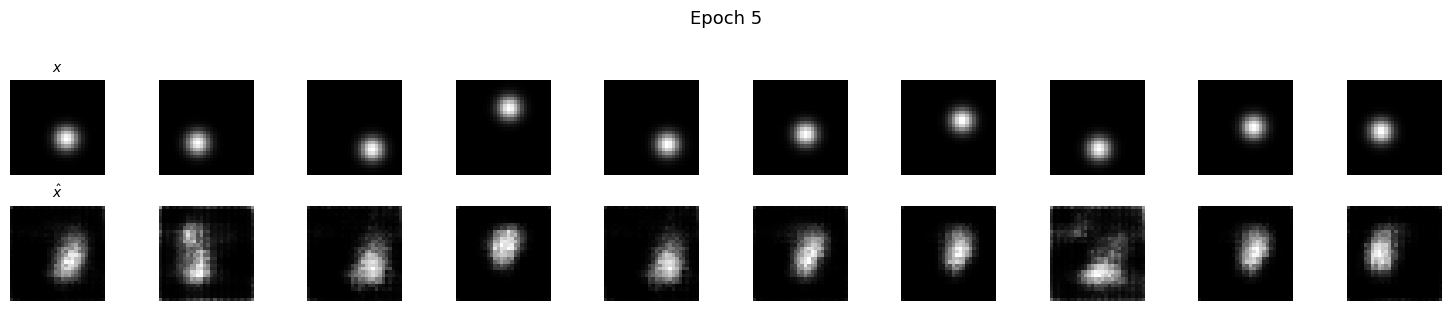

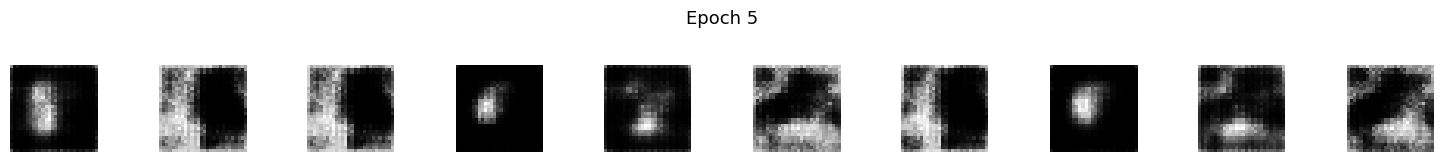

Epoch   6/25 Recon=0.10 D=1.0589 G=1.2191
Epoch   7/25 Recon=0.09 D=1.1072 G=1.1349
Epoch   8/25 Recon=0.09 D=1.1132 G=1.0997
Epoch   9/25 Recon=0.09 D=1.1287 G=1.0631
Epoch  10/25 Recon=0.09 D=1.3505 G=0.9750


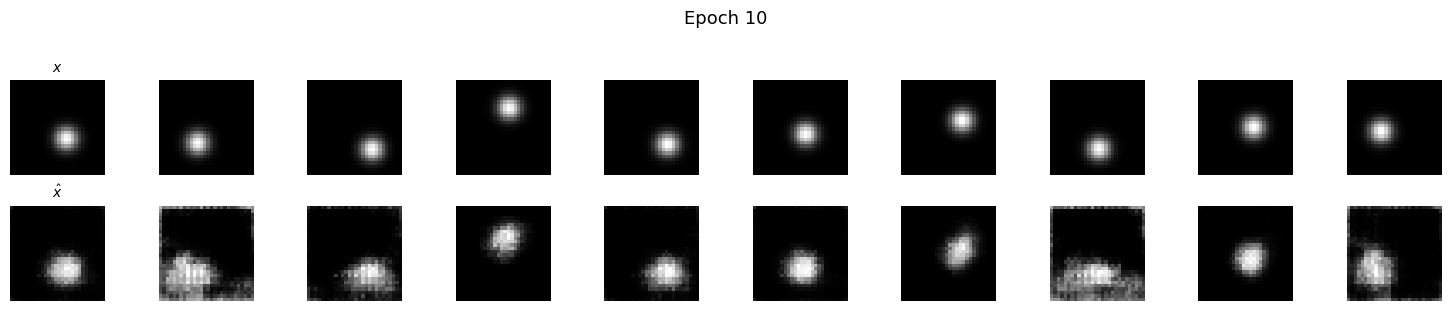

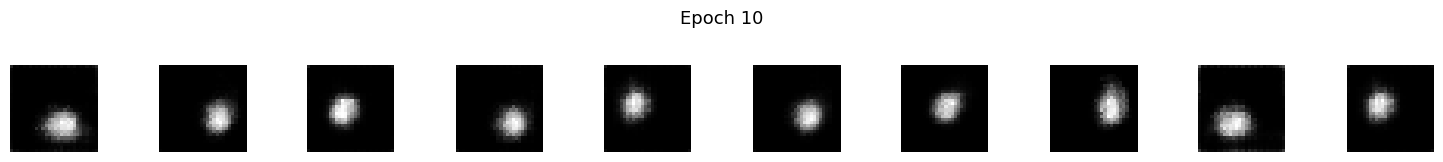

Epoch  11/25 Recon=0.10 D=1.5134 G=0.8418
Epoch  12/25 Recon=0.08 D=1.4425 G=0.7096
Epoch  13/25 Recon=0.08 D=1.4084 G=0.6779
Epoch  14/25 Recon=0.08 D=1.3884 G=0.7061
Epoch  15/25 Recon=0.08 D=1.3843 G=0.6938


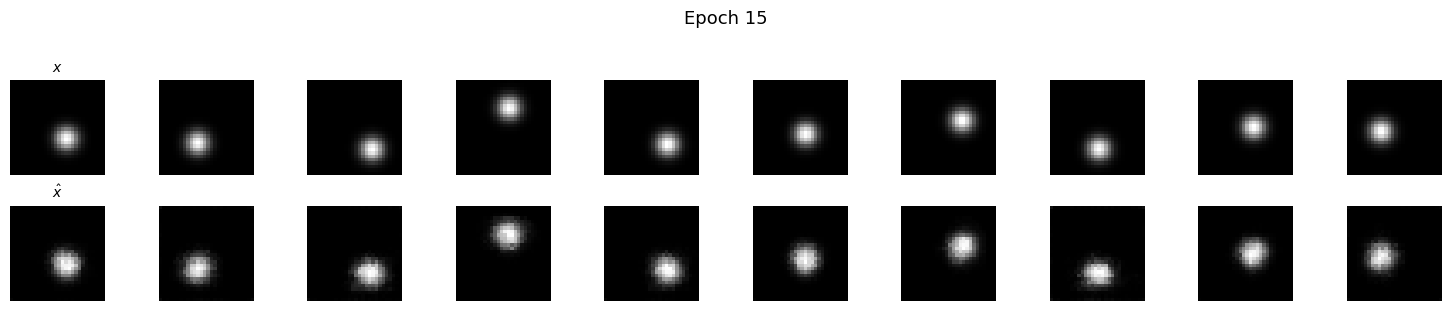

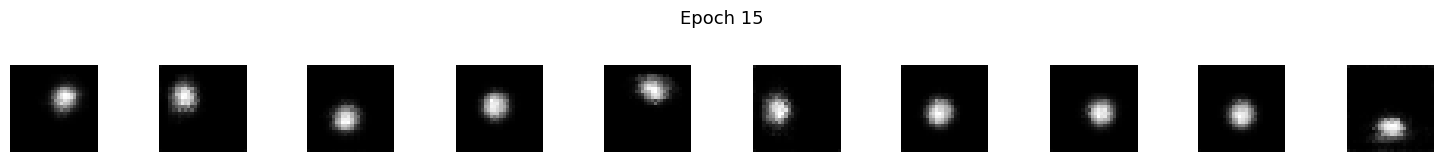

Epoch  16/25 Recon=0.08 D=1.3815 G=0.7024
Epoch  17/25 Recon=0.08 D=1.3773 G=0.7052
Epoch  18/25 Recon=0.08 D=1.3767 G=0.7048
Epoch  19/25 Recon=0.07 D=1.3793 G=0.7024
Epoch  20/25 Recon=0.07 D=1.3781 G=0.7066


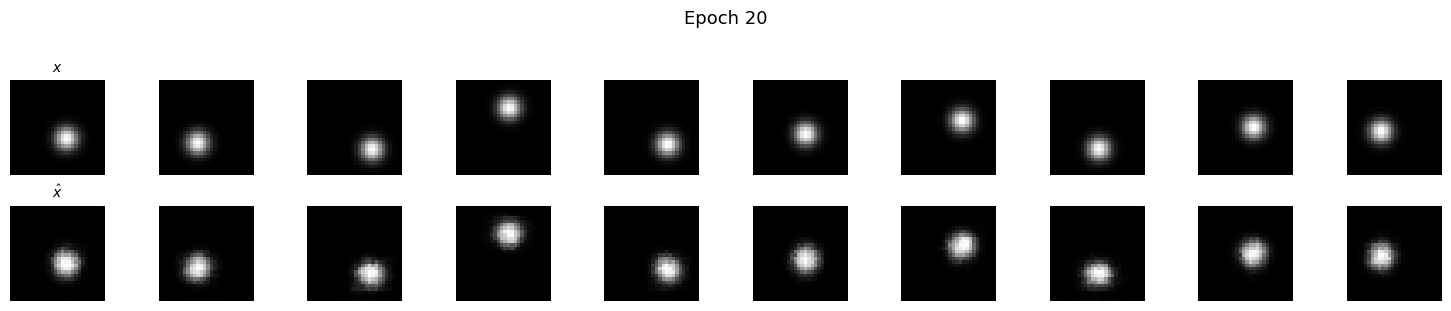

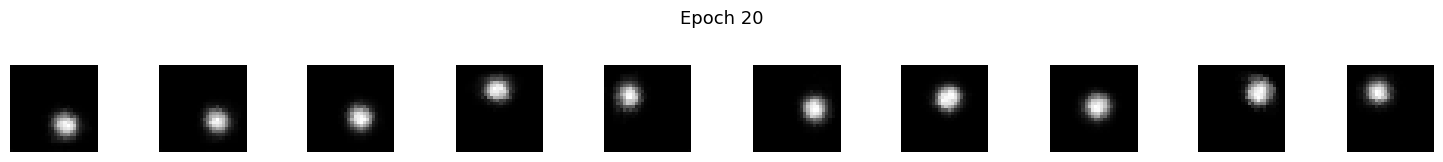

Epoch  21/25 Recon=0.07 D=1.3790 G=0.7038
Epoch  22/25 Recon=0.07 D=1.3799 G=0.7065
Epoch  23/25 Recon=0.07 D=1.3838 G=0.7060
Epoch  24/25 Recon=0.07 D=1.3829 G=0.7052
Epoch  25/25 Recon=0.07 D=1.3822 G=0.7093


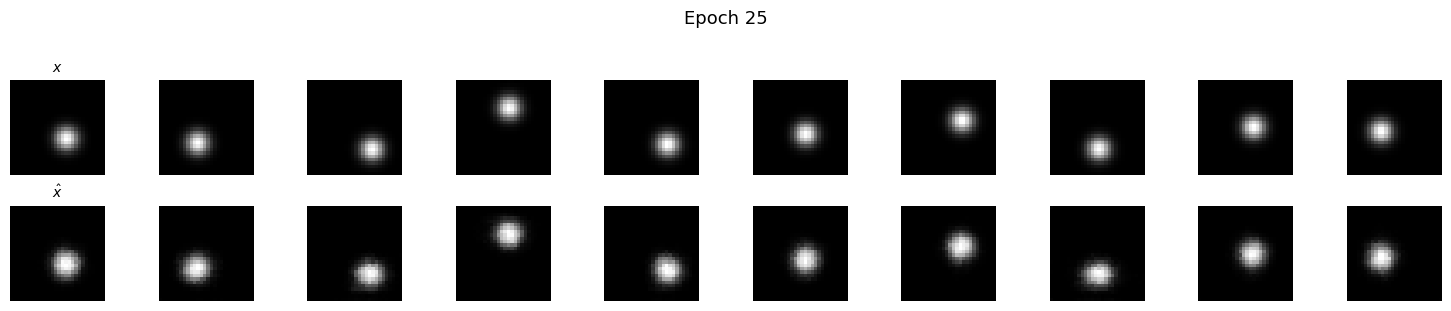

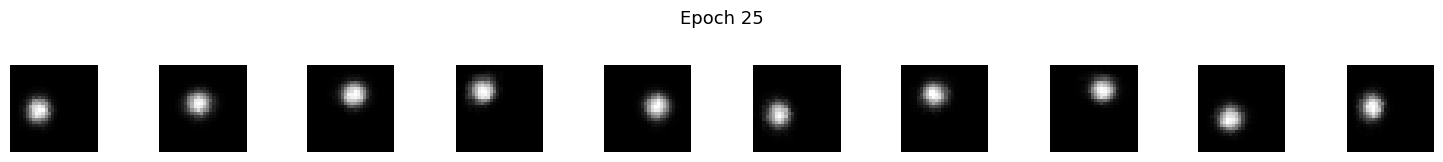

In [96]:
seed_everything(9951)

aae = AdversarialAutoencoder(
    hidden_channels=hidden_channels,
    latent_dim=latent_dim,
).to(device)

history = train_aae(aae, train_loader, epochs=epochs, lr=lr, lr_reg=lr_reg)

### 4. Evaluation

Evaluates the trained model on the hidden test set. **Do not alter this section.**

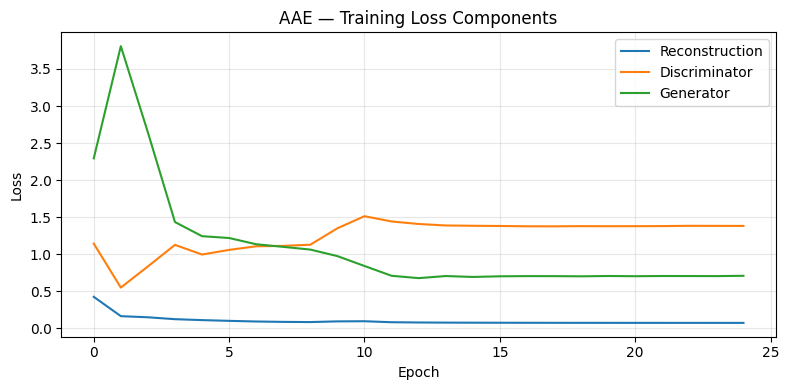

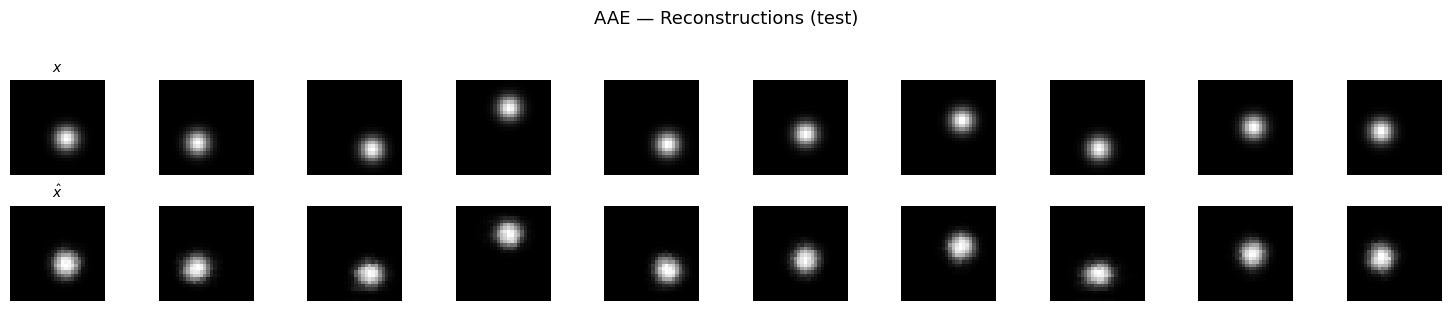

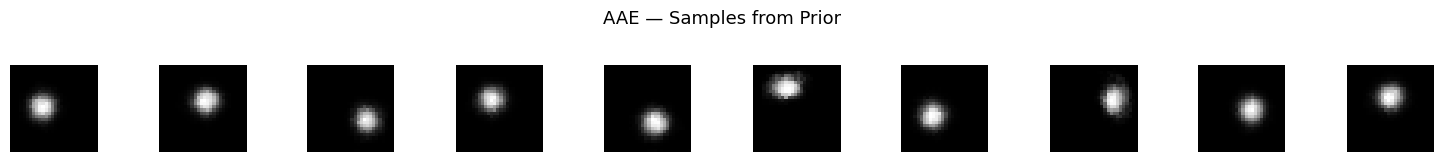

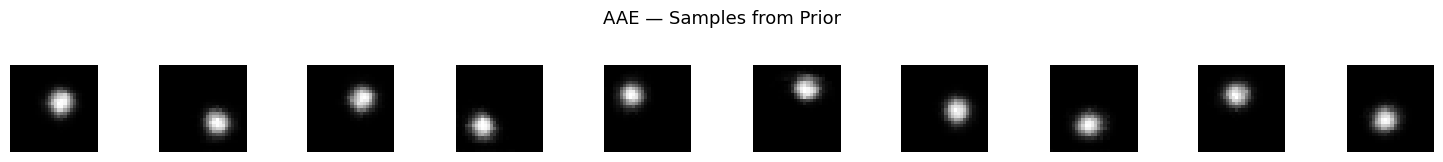

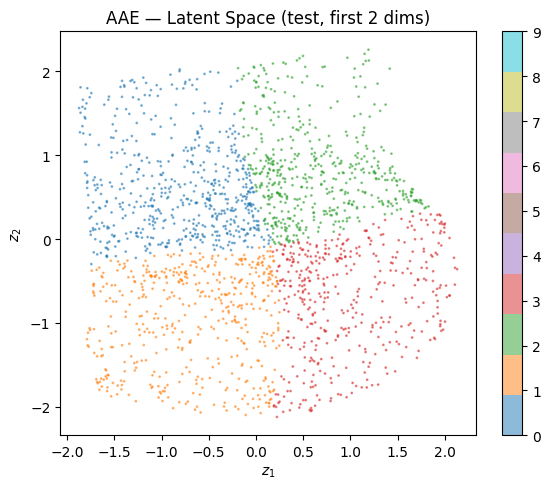

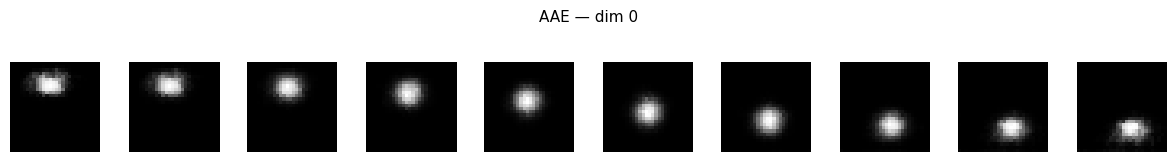

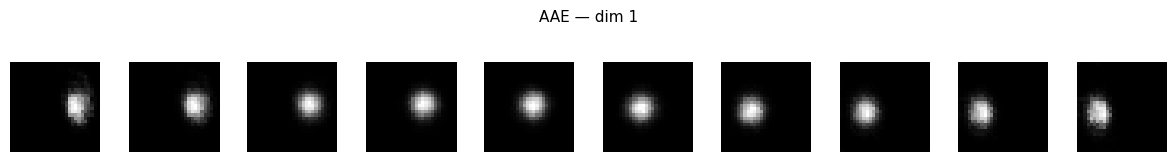

Discriminator accuracy (real vs. fake): 0.5137  (ideal ≈ 0.50)


0.513671875

In [97]:
plot_losses(history, "AAE — Training Loss Components")
show_reconstructions(aae, test_loader, title="AAE — Reconstructions (test)")
show_samples(aae, n=10, title="AAE — Samples from Prior")
show_samples(aae, n=10, title="AAE — Samples from Prior")
show_latent_space(aae, test_loader, title="AAE — Latent Space (test, first 2 dims)")
for dim in range(latent_dim):
    show_latent_traversal(aae, dim_to_traverse=dim, title="AAE")
discriminator_accuracy(aae, test_loader)